# Predicting Online Shopper Purchase Intention

## Executive summary

This project builds an end-to-end binary classification workflow to predict whether an e-commerce browsing session will end in revenue.

**Dataset**

The [UCI Online Shoppers Purchasing Intention dataset](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset) contains 12,330 browsing sessions collected over one year. The original study constructed the data so that each session represented a different user, reducing dependence on repeated behavior from a single visitor.

**Business question**

Can session-level behavioral signals identify shoppers who are likely to purchase, so that product, marketing, or site-experience teams can prioritize timely interventions for conversion?

**Headline result**

A tuned Random Forest achieved **0.927 test ROC-AUC** and **0.738 PR-AUC** against a **0.155 purchase-rate baseline**. Removing `PageValues` reduced test ROC-AUC to **0.761**, showing that model performance depends heavily on a feature that may behave like a target proxy depending on production timing.

## Dataset overview

The original paper clarifies several feature definitions that matter for interpretation:

- `Administrative` counts visits to account-management pages.
- `Informational` counts visits to site, communication, and address-information pages.
- `ProductRelated` counts visits to product pages.
- `BounceRates`, `ExitRates`, and `PageValues` are Google Analytics metrics aggregated across pages visited during the session.
- `SpecialDay` measures proximity to a commercially relevant date while accounting for ordering and delivery time.

`PageValues` is not the monetary value of the current session or transaction. It is the session-level average of page-level values derived from how strongly the pages visited have historically been associated with transactions. This makes it potentially valuable at prediction time if it is calculated exclusively from prior sessions and frozen before scoring the current visit. However, it may leak outcome information if the current or future transaction contributes to the value. Because the public dataset does not document that timing, I treat it as a potential target proxy and evaluate models both with and without it.

---
# 1. Setup and Data Loading

In [53]:
import warnings
from pathlib import Path
import os

# To silence plt warning
os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path.cwd() / ".matplotlib_cache"),
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import randint
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

In [54]:
local_data = Path("online_shoppers_intention.csv")
source_url = "https://raw.githubusercontent.com/omar-fitian/Online-Shoppers-Purchasing-Intention-Dataset/refs/heads/main/online_shoppers_intention.csv"

df = pd.read_csv(local_data if local_data.exists() else source_url)

# Variable type alignment
variable_types = {
    "Region": "category",
    "Revenue": "bool",
    "OperatingSystems": "category",
    "TrafficType": "category",
    "VisitorType": "category",
    "Weekend": "bool",
    "Browser": "category",
    "Month": "category",
}

df = df.astype(variable_types)

# Define the chronological order for months
month_order = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'June',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)


df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


---
# 2. Exploratory Data Analysis

In [55]:
pd.Series(
    {
        "sessions": len(df),
        "features_including_target": df.shape[1],
        "purchase_rate": df["Revenue"].mean(),
        "non_purchase_rate": 1 - df["Revenue"].mean(),
    }
).to_frame("value")

,value
sessions,12330.000000
features_including_target,18.000000
purchase_rate,0.154745
non_purchase_rate,0.845255


In [56]:
missing_summary = df.isna().sum().to_frame("missing_values")
missing_summary[missing_summary["missing_values"] > 0]

,missing_values


The dataset contains no missing values. I still check internal consistency between page-count fields and duration fields because session logs can contain structurally odd records even when no values are null.

In [57]:
duration_pairs = [
    ("Administrative", "Administrative_Duration"),
    ("Informational", "Informational_Duration"),
    ("ProductRelated", "ProductRelated_Duration"),
]

consistency_checks = []
for count_col, duration_col in duration_pairs:
    positive_duration_without_visit = ((df[count_col] == 0) & (df[duration_col] > 0)).sum()
    visit_with_zero_duration = ((df[count_col] > 0) & (df[duration_col] == 0)).sum()
    consistency_checks.append(
        {
            "page_family": count_col,
            "positive_duration_without_visit": positive_duration_without_visit,
            "visit_with_zero_duration": visit_with_zero_duration,
        }
    )

# Future note: How do these numbers change across target values?

pd.DataFrame(consistency_checks)

,page_family,positive_duration_without_visit,visit_with_zero_duration
0,Administrative,0,135
1,Informational,0,226
2,ProductRelated,0,717


No cases have positive duration without a corresponding page visit. Some sessions include visits with zero duration; I keep these rows because a page count can still be a valid behavioral signal and the rows are not internally impossible.

Now, let's explore how these numbers change across target values (`Revenue` True and False).

In [73]:
consistency_checks_by_revenue = []

for revenue_status in [True, False]:
    df_filtered = df[df["Revenue"] == revenue_status]

    for count_col, duration_col in duration_pairs:
        zero_duration_visits = (
            (df_filtered[count_col] > 0)
            & (df_filtered[duration_col] == 0)
        ).sum()

        consistency_checks_by_revenue.append(
            {
                "Revenue": revenue_status,
                "page_family": count_col,
                "zero_duration_visits": zero_duration_visits,
                "share_of_sessions": zero_duration_visits / len(df_filtered),
            }
        )

pd.DataFrame(consistency_checks_by_revenue)

,Revenue,page_family,zero_duration_visits,share_of_sessions
0,True,Administrative,34,0.017820
1,True,Informational,48,0.025157
2,True,ProductRelated,7,0.003669
3,False,Administrative,101,0.009691
4,False,Informational,178,0.017079
5,False,ProductRelated,710,0.068125


The relationship differs by target value. Product-related visits with zero recorded duration are more common among non-purchasing sessions, while administrative and informational zero-duration visits are proportionally more common among purchasing sessions. These values may reflect very brief visits, tab behavior, tracking limits, or how session duration is measured.

In [59]:
target_balance = (
    df["Revenue"]
    .value_counts()
    .rename_axis("Revenue")
    .to_frame("sessions")
)
target_balance["share"] = target_balance["sessions"] / target_balance["sessions"].sum()
target_balance

,sessions,share
Revenue,,
False,10422,0.845255
True,1908,0.154745


Seeing that the target variable is unbalanced, I will use stratified sampling for the cross-validation step.

In [60]:
visitor_summary = (
    df.groupby("VisitorType", observed=True)
      .agg(
          sessions=("Revenue", "size"),
          purchases=("Revenue", "sum"),
          conversion_rate=("Revenue", "mean"),
      )
      .sort_values("conversion_rate", ascending=False)
)

visitor_summary

,sessions,purchases,conversion_rate
VisitorType,,,
New_Visitor,1694,422,0.249115
Other,85,16,0.188235
Returning_Visitor,10551,1470,0.139323


Returning visitors account for most sessions, but visitor type still carries useful behavioral information because conversion rates differ by segment. New visitors are most likely to make a purchase.

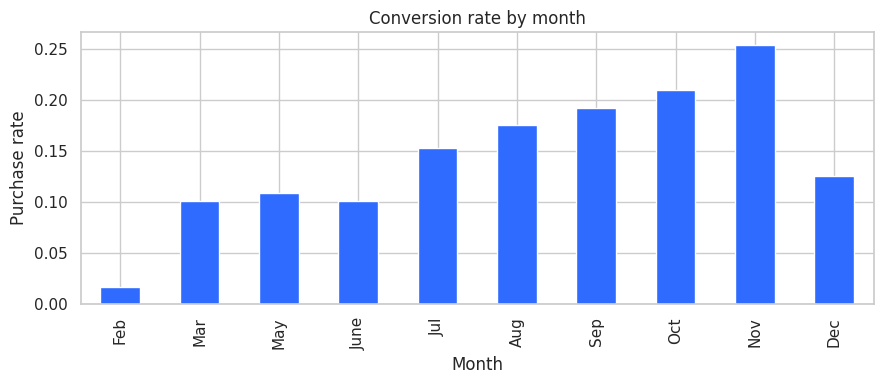

In [61]:
month_revenue = (
    df.groupby(["Month", "Revenue"], observed=True)
      .size()
      .unstack(fill_value=0)
)

month_revenue_prop = month_revenue.div(month_revenue.sum(axis=1), axis=0)

ax = month_revenue_prop[True].plot(
    kind="bar",
    figsize=(9, 4),
    color="#2F6BFF",
)
ax.set_title("Conversion rate by month")
ax.set_xlabel("Month")
ax.set_ylabel("Purchase rate")
plt.tight_layout()
plt.show()

Month captures seasonal purchasing patterns. November has the highest observed conversion rate in the dataset, which may reflect seasonal promotions or year-end shopping behavior. The available data do not establish the cause.

In [62]:
weekend_summary = (
    df.groupby("Weekend", observed=True)
      .agg(
          sessions=("Revenue", "size"),
          purchases=("Revenue", "sum"),
          conversion_rate=("Revenue", "mean"),
      )
)

weekend_summary

,sessions,purchases,conversion_rate
Weekend,,,
False,9462,1409,0.148911
True,2868,499,0.173989


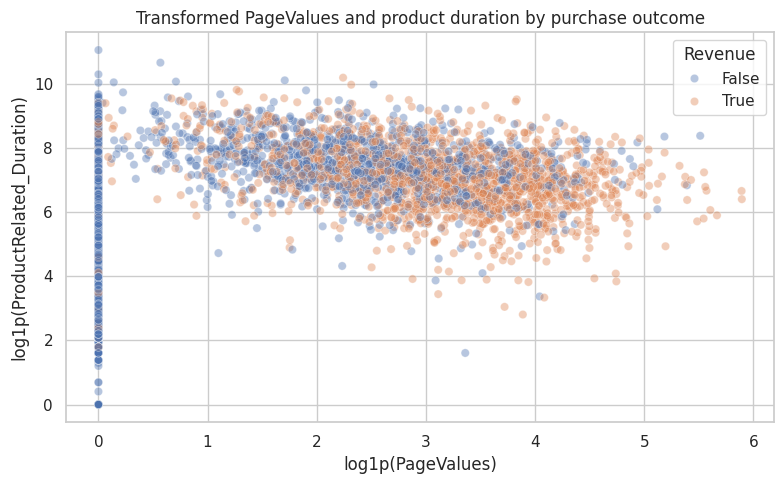

In [63]:
plot_df = df.assign(
    LogPageValues=np.log1p(df["PageValues"]),
    LogProductDuration=np.log1p(df["ProductRelated_Duration"]),
)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_df,
    x="LogPageValues",
    y="LogProductDuration",
    hue="Revenue",
    alpha=0.4,
)
plt.title("Transformed PageValues and product duration by purchase outcome")
plt.xlabel("log1p(PageValues)")
plt.ylabel("log1p(ProductRelated_Duration)")
plt.tight_layout()
plt.show()

The scatterplot suggests that higher PageValues is moderately associated with purchasing, while product-related duration alone provides less obvious separation between purchasing and non-purchasing sessions.

## EDA takeaways

Purchasing behavior is associated with product-focused engagement, higher `PageValues`, and seasonal variation. Several interaction variables are highly right-skewed with a large mass at zero, which is typical of session-level ecommerce data rather than automatic evidence of poor data quality. Because the target is imbalanced, the modeling section uses stratified validation and reports class-aware metrics instead of relying on accuracy alone.

---
# 3. Preprocessing

In [64]:
class DurationFeatureTransformer(BaseEstimator, TransformerMixin):
    """Create log-duration and observed-time features for duration columns."""

    def fit(self, X, y=None):
        self.feature_names_in_ = list(getattr(X, "columns", range(np.asarray(X).shape[1])))
        return self

    def transform(self, X):
        arr = np.asarray(X, dtype=float)
        return np.hstack([np.log1p(arr), (arr > 0).astype(float)])

    def get_feature_names_out(self, input_features=None):
        features = list(input_features if input_features is not None else self.feature_names_in_)
        log_names = [f"{feature}_LogDuration" for feature in features]
        observed_names = [f"{feature}_TimeObserved" for feature in features]
        return np.array(log_names + observed_names, dtype=object)


categorical_features = [
    "Month",
    "VisitorType",
    "Browser",
    "Region",
    "TrafficType",
    "OperatingSystems",
]
duration_features = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
]
numeric_features = [
    "Administrative",
    "Informational",
    "ProductRelated",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
]
binary_features = ["Weekend"]


def make_preprocessor(include_pagevalues=True):
    selected_numeric = (
        numeric_features
        if include_pagevalues
        else [feature for feature in numeric_features if feature != "PageValues"]
    )
    return ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("duration", DurationFeatureTransformer(), duration_features),
            ("numeric", "passthrough", selected_numeric),
            ("binary", "passthrough", binary_features),
        ],
        verbose_feature_names_out=False,
    )

---
# 4. Model Training and Evaluation

In [65]:
X = df.drop(columns=["Revenue"])
y = df["Revenue"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

pd.Series(
    {
        "baseline_accuracy": accuracy_score(y_test, baseline_pred),
        "baseline_positive_f1": f1_score(y_test, baseline_pred, zero_division=0),
        "positive_class_prevalence": y_test.mean(),
    }
).to_frame("value")

,value
baseline_accuracy,0.845093
baseline_positive_f1,0.000000
positive_class_prevalence,0.154907


In [66]:
def make_rf_pipeline(include_pagevalues=True, **model_params):
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor(include_pagevalues=include_pagevalues)),
            ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **model_params)),
        ]
    )


def make_rf_search(include_pagevalues=True):
    param_distributions = {
        "model__max_depth": [None, 10, 20, 30, 40],
        "model__min_samples_split": randint(2, 25),
        "model__min_samples_leaf": randint(1, 15),
        "model__max_features": ["sqrt", "log2", None],
    }
    return RandomizedSearchCV(
        estimator=make_rf_pipeline(include_pagevalues=include_pagevalues),
        param_distributions=param_distributions,
        n_iter=15,
        scoring="roc_auc",
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


rf_search = make_rf_search(include_pagevalues=True)
rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
print("Best CV ROC-AUC:", rf_search.best_score_)

Best params: {'model__max_depth': 30, 'model__max_features': None, 'model__min_samples_leaf': 12, 'model__min_samples_split': 8}
Best CV ROC-AUC: 0.9310727919973768


## Threshold selection without test-set leakage

The classification threshold is selected using out-of-fold predictions from the training set to maximize positive-class F1. The threshold is fixed before evaluating the held-out test set.

In [67]:
def select_threshold_from_training(model, X_train, y_train):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    train_oof_proba = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1,
    )[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_train, train_oof_proba)
    f1_scores = (
        2 * precision[:-1] * recall[:-1]
        / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    )
    return thresholds[np.argmax(f1_scores)]


def evaluate_classifier(model, X_test, y_test, threshold):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    metrics = pd.Series(
        {
            "threshold": threshold,
            "ROC-AUC": roc_auc_score(y_test, y_proba),
            "PR-AUC": average_precision_score(y_test, y_proba),
            "positive_prevalence": y_test.mean(),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0),
        }
    )
    return metrics, y_pred, y_proba


best_rf = rf_search.best_estimator_
selected_threshold = select_threshold_from_training(best_rf, X_train, y_train)
rf_metrics, rf_pred, rf_proba = evaluate_classifier(
    best_rf,
    X_test,
    y_test,
    selected_threshold,
)

print("Training-selected threshold:", selected_threshold)
rf_metrics.round(3).to_frame("Random Forest with PageValues")

Training-selected threshold: 0.3920889665413515


,Random Forest with PageValues
threshold,0.392
ROC-AUC,0.927
PR-AUC,0.738
positive_prevalence,0.155
Accuracy,0.894
Precision,0.657
Recall,0.662
F1,0.660


In [68]:
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred, zero_division=0))

[[1952  132]
 [ 129  253]]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2084
           1       0.66      0.66      0.66       382

    accuracy                           0.89      2466
   macro avg       0.80      0.80      0.80      2466
weighted avg       0.89      0.89      0.89      2466



ROC-AUC evaluates ranking quality across thresholds. PR-AUC focuses more directly on the minority purchase class. The model's PR-AUC is far above the purchase-rate baseline, which indicates that it is doing more than simply reflecting class prevalence.

## Sensitivity test: with and without `PageValues`

Because `PageValues` is derived from historical transaction associations, I treat it as a potential target-proxy or leakage-risk feature. It is not necessarily leakage if the value is calculated historically and available before the current prediction, but the static dataset does not make that timing completely transparent. I therefore report model performance both with and without `PageValues`.

In [69]:
rf_no_pagevalues_search = make_rf_search(include_pagevalues=False)
rf_no_pagevalues_search.fit(X_train.drop(columns=["PageValues"]), y_train)

best_rf_no_pagevalues = rf_no_pagevalues_search.best_estimator_
threshold_no_pagevalues = select_threshold_from_training(
    best_rf_no_pagevalues,
    X_train.drop(columns=["PageValues"]),
    y_train,
)

rf_no_pagevalues_metrics, rf_no_pagevalues_pred, rf_no_pagevalues_proba = evaluate_classifier(
    best_rf_no_pagevalues,
    X_test.drop(columns=["PageValues"]),
    y_test,
    threshold_no_pagevalues,
)

pd.DataFrame(
    {
        "With PageValues": rf_metrics,
        "Without PageValues": rf_no_pagevalues_metrics,
    }
).round(3)

,With PageValues,Without PageValues
threshold,0.392,0.208
ROC-AUC,0.927,0.761
PR-AUC,0.738,0.359
positive_prevalence,0.155,0.155
Accuracy,0.894,0.726
Precision,0.657,0.304
Recall,0.662,0.597
F1,0.660,0.403


Removing `PageValues` reduces test ROC-AUC from roughly 0.927 to 0.761 and PR-AUC from roughly 0.738 to 0.359. Threshold-based metrics are reported with separately selected training-only thresholds, but they should still be interpreted cautiously because the two models' probability distributions differ.

## Comparison model: logistic regression

In [70]:
logit = Pipeline(
    steps=[
        ("preprocess", make_preprocessor(include_pagevalues=True)),
        ("scale", StandardScaler(with_mean=False)),
        (
            "model",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logit.fit(X_train, y_train)

logit_threshold = select_threshold_from_training(
    logit,
    X_train,
    y_train,
)

logit_metrics, logit_pred, logit_proba = evaluate_classifier(
    logit,
    X_test,
    y_test,
    threshold=logit_threshold,
)

logit_metrics.round(3).to_frame(
    "Class-weighted logistic regression"
)

,Class-weighted logistic regression
threshold,0.629
ROC-AUC,0.893
PR-AUC,0.622
positive_prevalence,0.155
Accuracy,0.881
Precision,0.608
Recall,0.647
F1,0.627


The simpler logistic model has lower ROC-AUC than the Random Forest, but it provides a useful benchmark and illustrates a different precision-recall tradeoff.

---
# 5. Interpretation

In [71]:
perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_summary = (
    pd.DataFrame(
        {
            "feature": X_test.columns,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .head(12)
)

permutation_summary

,feature,importance_mean,importance_std
8,PageValues,0.304835,0.006954
10,Month,0.058456,0.004789
1,Administrative_Duration,0.006113,0.000946
4,ProductRelated,0.003700,0.001596
6,BounceRates,0.002798,0.000169
7,ExitRates,0.002747,0.001006
5,ProductRelated_Duration,0.002570,0.000909
0,Administrative,0.002134,0.000986
15,VisitorType,0.001141,0.000145
2,Informational,0.000382,0.000292


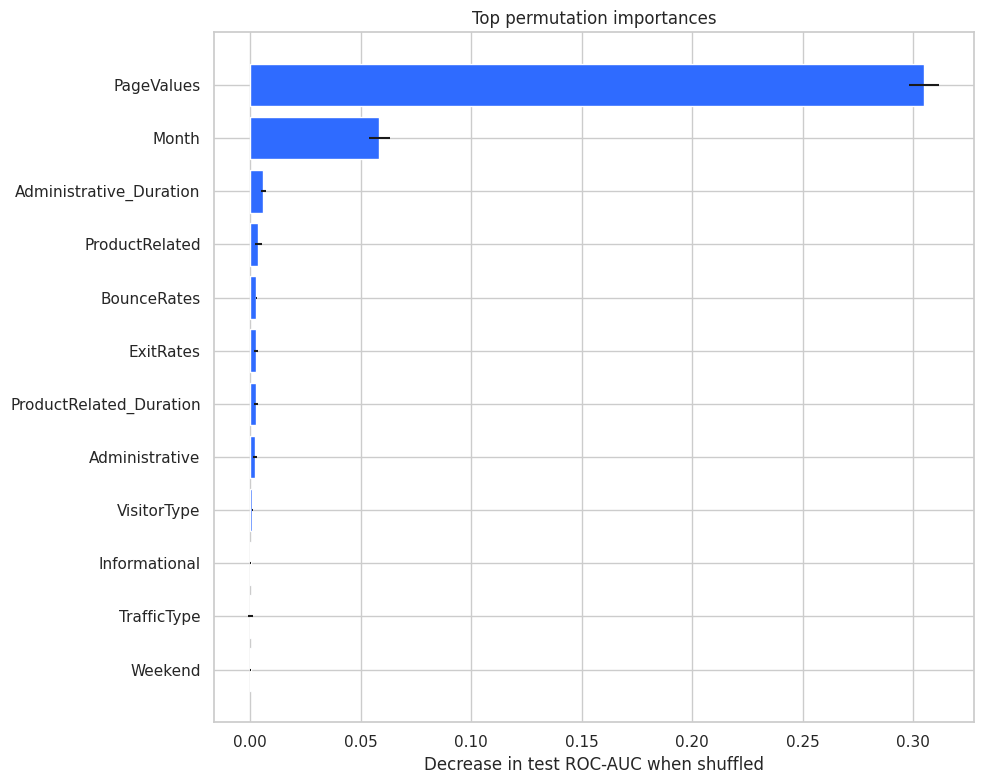

In [72]:
top_perm = permutation_summary.sort_values("importance_mean")

plt.figure(figsize=(10, 8))
plt.barh(
    top_perm["feature"],
    top_perm["importance_mean"],
    xerr=top_perm["importance_std"],
    color="#2F6BFF",
)
plt.xlabel("Decrease in test ROC-AUC when shuffled")
plt.title("Top permutation importances")
plt.tight_layout()
plt.show()

Permutation importance confirms that `PageValues` is the dominant signal. It also shows that month, administrative duration, product engagement, bounce rate, and exit rate contribute information, though several of these behavioral features are likely correlated. This is more reliable than plotting impurity importance for every one-hot encoded dummy variable.

## Comparison with the original study

For purchase-intention prediction, the original paper compared decision trees, Random Forest, SVM, and MLP models. On the original imbalanced data, its Random Forest reached about 89.5% accuracy but only about 0.58 positive-class F1, which reinforces why accuracy alone is misleading. After oversampling, the strongest MLP results reached about 0.86-0.87 F1.

In a separate module using sequential clickstream data, the paper trained an LSTM to predict imminent site abandonment. That abandonment model used a separate sequential dataset and is not directly comparable to the purchase-intention classifiers in this notebook.

My results are not directly comparable because this notebook optimizes ROC-AUC, uses a different train/test split, uses training-only threshold selection, does not oversample, and uses a different preprocessing and hyperparameter search setup. The main takeaway is that this notebook demonstrates strong ranking performance and a transparent validation workflow, while the paper emphasizes balanced classification and a broader real-time intervention system.

---
# 6. Conclusion

This project demonstrates a reusable applied machine-learning workflow for an imbalanced ecommerce classification problem. During hyperparameter tuning, the selected Random Forest achieved a best mean three-fold validation ROC-AUC of about *0.931*, a held-out test ROC-AUC of about **0.927**, and a PR-AUC of about **0.738** against a purchase-rate baseline of about **0.155**. The classification threshold was selected from training-only out-of-fold predictions before evaluating the held-out test set.

The most important modeling caveat is the role of `PageValues`. Removing it reduced test ROC-AUC from about **0.927** to **0.761** and PR-AUC from about **0.738** to **0.359**. At separately selected training-only thresholds, positive-class F1 also fell, but threshold-based comparisons should be interpreted cautiously because the models' probability distributions differ.

In production, I would confirm whether `PageValues` is available before prediction time, validate probability calibration, compare threshold choices against intervention costs, monitor performance by traffic source and visitor type, and use permutation or SHAP-based explanations for stakeholder interpretation. Purchase-intention scores should also be combined with abandonment risk, expected intervention cost, and predicted incremental conversion so that promotions or recommendations are directed only toward visitors for whom intervention is likely to be useful.